# Exploratory Data Analysis Report for Shark Movement Forecasting: An Assessment for Ocean Recreational Safety

---
By: Isabella Parlato
Github Repository: https://github.com/ParlatoI/Shark-Forecasting_Capstone


First, I created two folders in the colab content files section titled "buoy_41009" and "buoy_41010" to which I uploaded all of the years of respective buoy data per buoy as shown in the Github repository from the following folders in raw_datasets: buoy_41009_txt_2010-2019 and buoy_41010_txt_2010-2019

In [1]:
# consolidate buoys txt files for 41010 & 41009 into buoy csv's with all years

import pandas as pd
import glob
import os

def combine_buoy_txt_to_csv(folder_path, buoy_prefix, output_csv):
    all_files = sorted(glob.glob(os.path.join(folder_path, f"{buoy_prefix}*.txt")))
    df_list = []

    for file in all_files:
        print(f"Loading: {file}")

        # Read first row for column names
        with open(file, 'r') as f:
            header_line = f.readline().strip()  # correct column names
            _ = f.readline()  # skip 2nd row (units)

        col_names = header_line.split()

        # Load data, starting from row 3
        df = pd.read_csv(
            file,
            sep=r'\s+',
            skiprows=2,   # skip the units row
            names=col_names,
            engine='python'
        )

        # Create datetime column if available
        date_cols = ['#yr', 'mo', 'dy', 'hr', 'mn']
        if all(col in df.columns for col in date_cols):
            df['datetime'] = pd.to_datetime(
                df[date_cols].rename(columns={
                    '#yr': 'year',
                    'mo': 'month',
                    'dy': 'day',
                    'hr': 'hour',
                    'mn': 'minute'
                }),
                errors='coerce'
            )
        else:
            print(f"⚠️ Missing date columns in: {file}")

        df_list.append(df)

    # Merge all years
    combined_df = pd.concat(df_list, ignore_index=True)

    # Save
    combined_df.to_csv(output_csv, index=False)
    print(f"✔️ Saved clean merged CSV: {output_csv}")

    return combined_df


# Run for both buoys
buoy_41009_df = combine_buoy_txt_to_csv("/content/buoy_41009", "41009h", "buoy_41009_combined.csv")
buoy_41010_df = combine_buoy_txt_to_csv("/content/buoy_41010", "41010h", "buoy_41010_combined.csv")


Loading: /content/buoy_41009/41009h2010.txt
⚠️ Missing date columns in: /content/buoy_41009/41009h2010.txt
Loading: /content/buoy_41009/41009h2011.txt
⚠️ Missing date columns in: /content/buoy_41009/41009h2011.txt
Loading: /content/buoy_41009/41009h2012.txt
⚠️ Missing date columns in: /content/buoy_41009/41009h2012.txt
Loading: /content/buoy_41009/41009h2013.txt
⚠️ Missing date columns in: /content/buoy_41009/41009h2013.txt
Loading: /content/buoy_41009/41009h2014.txt
⚠️ Missing date columns in: /content/buoy_41009/41009h2014.txt
Loading: /content/buoy_41009/41009h2015.txt
⚠️ Missing date columns in: /content/buoy_41009/41009h2015.txt
Loading: /content/buoy_41009/41009h2016.txt
⚠️ Missing date columns in: /content/buoy_41009/41009h2016.txt
Loading: /content/buoy_41009/41009h2017.txt
⚠️ Missing date columns in: /content/buoy_41009/41009h2017.txt
Loading: /content/buoy_41009/41009h2018.txt
⚠️ Missing date columns in: /content/buoy_41009/41009h2018.txt
Loading: /content/buoy_41009/41009h20

In [2]:
# inspect to make sure merged properly

# For buoy 41009
df_41009 = pd.read_csv("buoy_41009_combined.csv")
print("Buoy 41009 Summary:")
print(df_41009.info())        # Check column types and non-null counts
print(df_41009.head())        # Look at first few rows
print(df_41009.describe())    # Summary statistics for numeric columns

# For buoy 41010
df_41010 = pd.read_csv("buoy_41010_combined.csv")
print("\nBuoy 41010 Summary:")
print(df_41010.info())
print(df_41010.head())
print(df_41010.describe())

# Check number of rows per buoy
print(f"\nBuoy 41009 rows: {len(df_41009)}")
print(f"Buoy 41010 rows: {len(df_41010)}")


Buoy 41009 Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253464 entries, 0 to 253463
Data columns (total 18 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   #YY     253464 non-null  int64  
 1   MM      253464 non-null  int64  
 2   DD      253464 non-null  int64  
 3   hh      253464 non-null  int64  
 4   mm      253464 non-null  int64  
 5   WDIR    253464 non-null  int64  
 6   WSPD    253464 non-null  float64
 7   GST     253464 non-null  float64
 8   WVHT    253464 non-null  float64
 9   DPD     253464 non-null  float64
 10  APD     253464 non-null  float64
 11  MWD     253464 non-null  int64  
 12  PRES    253464 non-null  float64
 13  ATMP    253464 non-null  float64
 14  WTMP    253464 non-null  float64
 15  DEWP    253464 non-null  float64
 16  VIS     253464 non-null  float64
 17  TIDE    253464 non-null  float64
dtypes: float64(11), int64(7)
memory usage: 34.8 MB
None
    #YY  MM  DD  hh  mm  WDIR  WSPD   GST  WVHT   DP

Note from https://www.ndbc.noaa.gov/faq/measdes.shtml: "Real Time files generally contain the last 45 days of "Realtime" data - data that went through automated quality checks and were distributed as soon as they were received. Historical files have gone through post-processing analysis and represent the data sent to the archive centers. The formats for both are generally the same, with the major difference being the treatment of missing data. Missing data in the Realtime files are denoted by "MM" while a variable number of 9's are used to denote missing data in the Historical files, depending on the data type (for example: 999.0 99.0)."



---


some of the original columns are mostly empty so for now planning on converting all of the missing value codes with NA/NaN to make that clear so the number placeholders don't get accidently used in stats. need to convert any numeric to float since int. can't use NaN. want to make sure proper date time type column creation

In [3]:
# verify column names
print("41009 Columns:")
print(df_41009.columns.tolist())

print("\n41010 Columns:")
print(df_41010.columns.tolist())


41009 Columns:
['#YY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'WVHT', 'DPD', 'APD', 'MWD', 'PRES', 'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE']

41010 Columns:
['#YY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'WVHT', 'DPD', 'APD', 'MWD', 'PRES', 'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE']


In [4]:
# initial cleaning for buoy datasets

import numpy as np
import pandas as pd

def clean_buoy_df_safe(df):
    # Rename year/month/day/hour/min columns
    df = df.rename(columns={"#YY": "year", "MM": "month", "DD": "day", "hh": "hour", "mm": "minute"})

    # Create datetime column (No KeyError now)
    df['datetime'] = pd.to_datetime(df[['year','month','day','hour','minute']], errors='coerce')

    # Replace NOAA missing value codes with np.nan
    missing_values = [99, 999, 9999]
    df = df.replace(missing_values, np.nan)

    # Convert only measurement columns (exclude datetime/time columns) to float
    time_cols = ['year','month','day','hour','minute']
    for col in df.columns:
        if col not in time_cols + ['datetime']:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

# Apply to both buoys
df_41009 = clean_buoy_df_safe(df_41009)
df_41010 = clean_buoy_df_safe(df_41010)

# Quick check
print(df_41009.info())
print(df_41010.info())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253464 entries, 0 to 253463
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   year      253464 non-null  int64         
 1   month     253464 non-null  int64         
 2   day       253464 non-null  int64         
 3   hour      253464 non-null  int64         
 4   minute    253464 non-null  int64         
 5   WDIR      252523 non-null  float64       
 6   WSPD      253392 non-null  float64       
 7   GST       253376 non-null  float64       
 8   WVHT      100891 non-null  float64       
 9   DPD       100728 non-null  float64       
 10  APD       100891 non-null  float64       
 11  MWD       57426 non-null   float64       
 12  PRES      248994 non-null  float64       
 13  ATMP      251909 non-null  float64       
 14  WTMP      207521 non-null  float64       
 15  DEWP      246604 non-null  float64       
 16  VIS       0 non-null       float64    

In [5]:
# quick summary of missing values (buoys datasets)

def missing_summary(df):
    missing = df.isna().sum()
    pct_missing = 100 * missing / len(df)
    summary = pd.DataFrame({'missing_count': missing, 'missing_pct': pct_missing})
    return summary.sort_values('missing_pct', ascending=False)

print("Buoy 41009 Missing Data:")
print(missing_summary(df_41009))

print("\nBuoy 41010 Missing Data:")
print(missing_summary(df_41010))


Buoy 41009 Missing Data:
          missing_count  missing_pct
VIS              253464   100.000000
TIDE             253464   100.000000
MWD              196038    77.343528
DPD              152736    60.259445
APD              152573    60.195136
WVHT             152573    60.195136
WTMP              45943    18.126046
DEWP               6860     2.706499
PRES               4470     1.763564
ATMP               1555     0.613499
WDIR                941     0.371256
GST                  88     0.034719
WSPD                 72     0.028406
year                  0     0.000000
month                 0     0.000000
day                   0     0.000000
hour                  0     0.000000
minute                0     0.000000
datetime              0     0.000000

Buoy 41010 Missing Data:
          missing_count  missing_pct
VIS              216990   100.000000
TIDE             216990   100.000000
MWD              181708    83.740265
DPD              127057    58.554311
APD              127001 

looking at above, planning to drop the columns with no data, which are the same in both buoy datasets: VIS and TIDE. Then create a new save for each dataset as a new baseline for each

In [6]:
# those columns with 100% missing values
drop_cols = ['TIDE', 'VIS']

# drop them
df_41009_clean = df_41009.drop(columns=drop_cols)
df_41010_clean = df_41010.drop(columns=drop_cols)

# save as new cleanner baseline CSVs
df_41009_clean.to_csv("buoy_41009_clean.csv", index=False)
df_41010_clean.to_csv("buoy_41010_clean.csv", index=False)

# quick check
print("Buoy 41009 cleaned shape:", df_41009_clean.shape)
print("Buoy 41010 cleaned shape:", df_41010_clean.shape)


Buoy 41009 cleaned shape: (253464, 17)
Buoy 41010 cleaned shape: (216990, 17)


## EDA focused
creation of tables and graphs for further analysis

In [7]:
# table for continuous descriptive buoy stats

#wind speed, gusts, water temp, air temp, wave height, dominant wave period, avg wave period, pressure, dew point, wind dir
buoy_cols = ['WSPD','GST','WTMP','ATMP','WVHT','DPD','APD','PRES','DEWP','WDIR']

table_41009 = df_41009_clean[buoy_cols].describe().T  # transpose for readability
table_41010 = df_41010_clean[buoy_cols].describe().T

# round to 2 dec place for presentation purposes
table_41009 = table_41009.round(2)
table_41010 = table_41010.round(2)

print("Buoy 41009 Summary Statistics:")
print(table_41009)
print("\nBuoy 41010 Summary Statistics:")
print(table_41010)


Buoy 41009 Summary Statistics:
         count     mean    std     min      25%      50%      75%      max
WSPD  253392.0     5.71   2.76    0.00     3.70     5.50     7.40    29.30
GST   253376.0     7.16   3.39    0.00     4.70     6.80     9.20    35.80
WTMP  207521.0    25.85   2.62   16.60    23.80    26.10    28.20    32.70
ATMP  251909.0    24.32   3.89    3.50    22.20    25.10    27.40    36.30
WVHT  100891.0     1.17   0.65    0.00     0.70     1.02     1.46     9.07
DPD   100728.0     8.16   2.52    2.25     6.67     8.33    10.00    19.05
APD   100891.0     5.17   1.09    2.70     4.41     5.02     5.78    17.81
PRES  248994.0  1017.69   4.08  975.40  1015.20  1017.80  1020.20  1032.40
DEWP  246604.0    19.16   5.23   -6.80    16.40    20.50    23.20    27.60
WDIR  252523.0   172.56  96.14    0.00    95.00   159.00   243.00   360.00

Buoy 41010 Summary Statistics:
         count     mean    std     min      25%      50%      75%      max
WSPD  216886.0     6.01   2.91    0.0

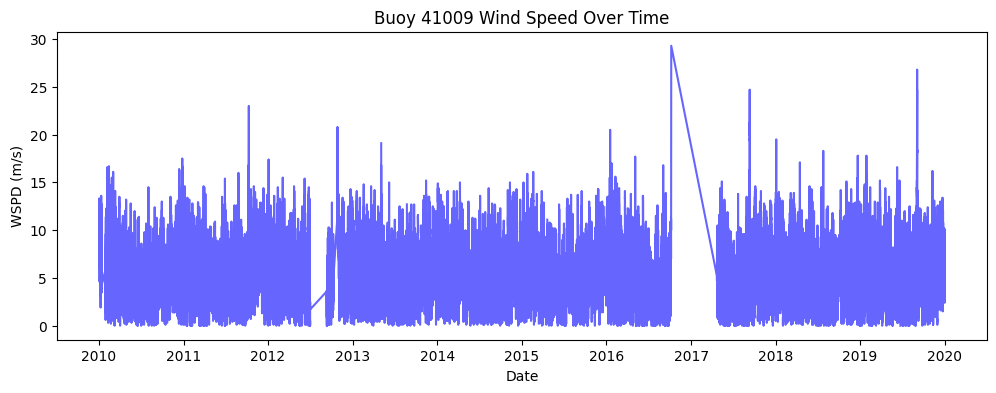

In [ ]:
# time series plot for WSPD

plt.figure(figsize=(12,4))
plt.plot(df_41009_clean['datetime'], df_41009_clean['WSPD'], color='blue', alpha=0.6)
plt.title("Buoy 41009 Wind Speed Over Time")
plt.xlabel("Date")
plt.ylabel("WSPD (m/s)")
plt.show()


Since similar weather pattern trends were seen between buoys, I just pulled a time series plot for one buoy's windspeed (WSPD). We can see extreme jumps at points but generally about 9 m/s to about 17 m/s. Those jumps must have been caused by extreme weather occurances.

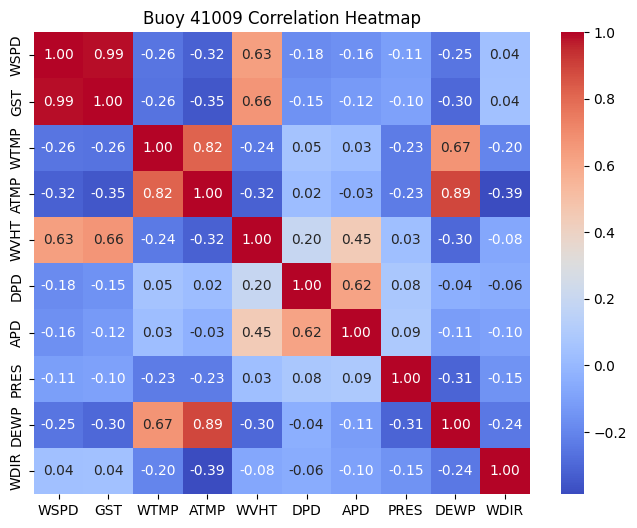

In [ ]:
# correlation heatmap - collinearity check

import seaborn as sns

plt.figure(figsize=(8,6))
corr_matrix = df_41009_clean[buoy_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Buoy 41009 Correlation Heatmap")
plt.show()


GST & WSPD are 0.99 so definitley need to drop one of them but will see which one has the more complete dataset first. Second highest at 0.89 correlation is DEWP & ATMP followed by ATMP & WTMP at 0.82. WTMP & DEWP followed at 0.67 correlation and GST & WVHT at 0.66. The only other variables in the 60's range were WVHT & WSPD at 0.63 and DPD & APD at 0.62

In [9]:
# Shark focused table & charts

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Regularized_tiger_shark_tracks dataset into content folder from raw_datasets then use below
sharks_df = pd.read_csv('/content/Regularized_tiger_shark_tracks.csv')

# shark summary table

# Number of unique sharks
num_sharks = sharks_df['Shark_ID'].nunique()
print(f"Number of unique sharks: {num_sharks}\n")

# Observations by Season
season_summary = sharks_df['Season'].value_counts().to_frame('count')
season_summary['percent'] = 100 * season_summary['count'] / len(sharks_df)
season_summary['percent'] = season_summary['percent'].round(1)
print("Observations by Season:")
print(season_summary, "\n")

# Observations by Year
year_summary = sharks_df['Year'].value_counts().sort_index().to_frame('count')
year_summary['percent'] = 100 * year_summary['count'] / len(sharks_df)
year_summary['percent'] = year_summary['percent'].round(1)
print("Observations by Year:")
print(year_summary)


Number of unique sharks: 47

Observations by Season:
        count  percent
Season                
Warm     3068     58.7
Cold     2159     41.3 

Observations by Year:
      count  percent
Year                
2010     73      1.4
2011   1782     34.1
2012    198      3.8
2013    105      2.0
2014    623     11.9
2015    570     10.9
2016    451      8.6
2017    213      4.1
2018    386      7.4
2019    826     15.8


### shark dataset visualizations

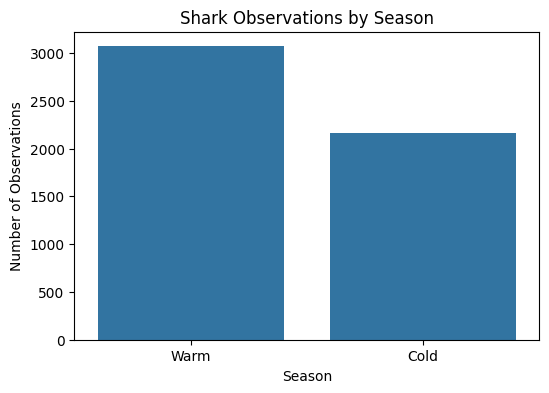

In [10]:
# Observations per Season
plt.figure(figsize=(6,4))
sns.countplot(data=sharks_df, x='Season', order=sharks_df['Season'].value_counts().index)
plt.title("Shark Observations by Season")
plt.xlabel("Season")
plt.ylabel("Number of Observations")
plt.show()

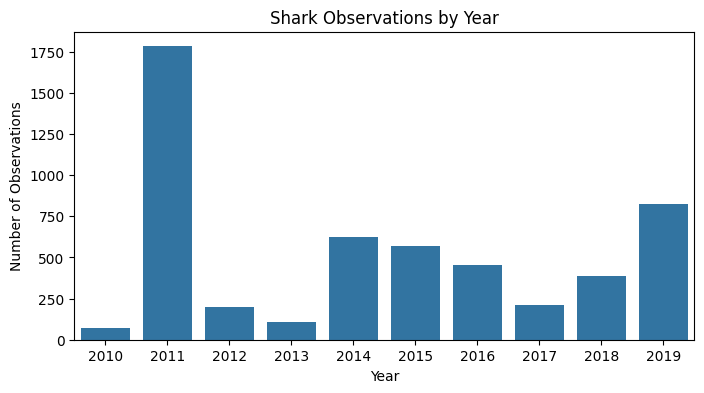

In [11]:
# Observations per Year
plt.figure(figsize=(8,4))
sns.countplot(data=sharks_df, x='Year', order=sorted(sharks_df['Year'].unique()))
plt.title("Shark Observations by Year")
plt.xlabel("Year")
plt.ylabel("Number of Observations")
plt.show()

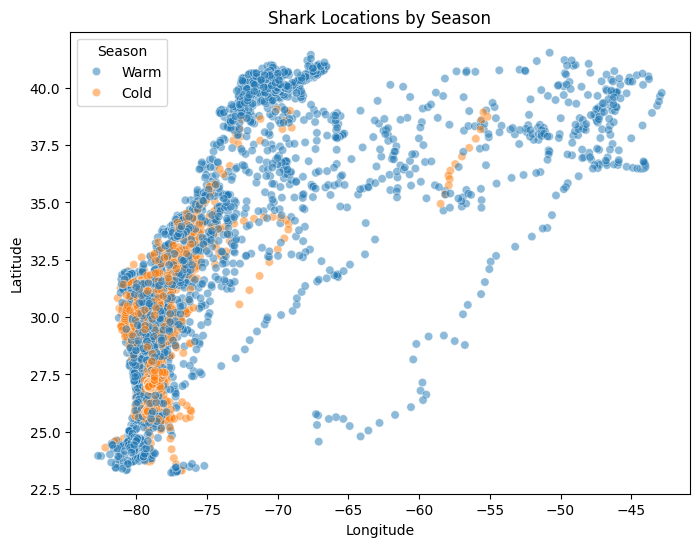

In [12]:
# Shark Locations by Season
plt.figure(figsize=(8,6))
sns.scatterplot(data=sharks_df, x='lon', y='lat', hue='Season', alpha=0.5)
plt.title("Shark Locations by Season")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title='Season')
plt.show()

### data dictionaries for current data sets

In [14]:
# data dict. buoy - df_41009_clean

import pandas as pd

# Create a basic data dictionary
data_dict = pd.DataFrame({
    'Variable': df_41009_clean.columns,
    'Data Type': df_41009_clean.dtypes,
    'Non-Null Count': df_41009_clean.notna().sum(),
    'Missing Count': df_41009_clean.isna().sum(),
    'Missing %': df_41009_clean.isna().mean() * 100,
    'Mean': df_41009_clean.mean(numeric_only=True),
    'Std': df_41009_clean.std(numeric_only=True),
    'Min': df_41009_clean.min(numeric_only=True),
    '25%': df_41009_clean.quantile(0.25, numeric_only=True),
    '50% (Median)': df_41009_clean.median(numeric_only=True),
    '75%': df_41009_clean.quantile(0.75, numeric_only=True),
    'Max': df_41009_clean.max(numeric_only=True)
}).reset_index(drop=True)

# Round numeric values for readability
data_dict = data_dict.round(2)

# Display the data dictionary
data_dict


,Variable,Data Type,Non-Null Count,Missing Count,Missing %,Mean,Std,Min,25%,50% (Median),75%,Max
0,year,float64,100891,152573,60.20,5.17,1.09,2.70,4.41,5.02,5.78,17.81
1,month,float64,251909,1555,0.61,24.32,3.89,3.50,22.20,25.10,27.40,36.30
2,day,float64,246604,6860,2.71,19.16,5.23,-6.80,16.40,20.50,23.20,27.60
3,hour,float64,100728,152736,60.26,8.16,2.52,2.25,6.67,8.33,10.00,19.05
4,minute,float64,253376,88,0.03,7.16,3.39,0.00,4.70,6.80,9.20,35.80
5,WDIR,float64,57426,196038,77.34,94.07,72.84,0.00,58.00,77.00,95.00,360.00
6,WSPD,float64,248994,4470,1.76,1017.69,4.08,975.40,1015.20,1017.80,1020.20,1032.40
7,GST,float64,252523,941,0.37,172.56,96.14,0.00,95.00,159.00,243.00,360.00
8,WVHT,float64,253392,72,0.03,5.71,2.76,0.00,3.70,5.50,7.40,29.30
9,DPD,float64,207521,45943,18.13,25.85,2.62,16.60,23.80,26.10,28.20,32.70


In [15]:
# data dict. buoy - df_41010_clean

import pandas as pd

# Create a basic data dictionary
data_dict = pd.DataFrame({
    'Variable': df_41010_clean.columns,
    'Data Type': df_41010_clean.dtypes,
    'Non-Null Count': df_41010_clean.notna().sum(),
    'Missing Count': df_41010_clean.isna().sum(),
    'Missing %': df_41010_clean.isna().mean() * 100,
    'Mean': df_41010_clean.mean(numeric_only=True),
    'Std': df_41010_clean.std(numeric_only=True),
    'Min': df_41010_clean.min(numeric_only=True),
    '25%': df_41010_clean.quantile(0.25, numeric_only=True),
    '50% (Median)': df_41010_clean.median(numeric_only=True),
    '75%': df_41010_clean.quantile(0.75, numeric_only=True),
    'Max': df_41010_clean.max(numeric_only=True)
}).reset_index(drop=True)

# Round numeric values for readability
data_dict = data_dict.round(2)

# Display the data dictionary
data_dict


,Variable,Data Type,Non-Null Count,Missing Count,Missing %,Mean,Std,Min,25%,50% (Median),75%,Max
0,year,float64,89989,127001,58.53,5.47,1.06,2.82,4.75,5.30,6.02,12.33
1,month,float64,212463,4527,2.09,25.00,3.38,9.70,22.80,25.50,28.00,35.40
2,day,float64,178608,38382,17.69,19.90,4.92,0.60,17.10,21.60,23.80,27.70
3,hour,float64,89933,127057,58.55,8.13,2.33,2.47,6.67,8.33,9.09,23.53
4,minute,float64,216495,495,0.23,7.65,3.54,0.00,5.10,7.20,9.70,38.60
5,WDIR,float64,35282,181708,83.74,117.84,76.93,0.00,69.00,103.00,128.00,360.00
6,WSPD,float64,206053,10937,5.04,1017.50,4.24,981.40,1015.10,1017.70,1020.10,1032.70
7,GST,float64,209100,7890,3.64,164.74,87.82,0.00,95.00,160.00,221.00,360.00
8,WVHT,float64,216886,104,0.05,6.01,2.91,0.00,4.00,5.80,7.80,28.30
9,DPD,float64,204444,12546,5.78,26.64,2.35,21.00,24.60,26.80,28.90,32.60


In [16]:
# shark dict

df_sharks = pd.read_csv('/content/Regularized_tiger_shark_tracks.csv')

# Simple data dictionary for shark data
shark_dict = pd.DataFrame({
    'Variable': df_sharks.columns,
    'Data Type': df_sharks.dtypes,
    'Non-Null Count': df_sharks.notna().sum(),
    'Missing Count': df_sharks.isna().sum(),
    'Missing %': df_sharks.isna().mean() * 100,
    'Unique Values': df_sharks.nunique()  # useful for categorical variables
}).reset_index(drop=True)

shark_dict


,Variable,Data Type,Non-Null Count,Missing Count,Missing %,Unique Values
0,Obs,int64,5227,0,0.0,5227
1,Shark_ID,int64,5227,0,0.0,47
2,lon,float64,5227,0,0.0,5227
3,lat,float64,5227,0,0.0,5227
4,Month,int64,5227,0,0.0,12
5,Day,int64,5227,0,0.0,31
6,Year,int64,5227,0,0.0,10
7,Season,object,5227,0,0.0,2


In [ ]:
# first download dataset from colab as ipynb then reupload to content folder
## now to convert to pdf

!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic
!sudo apt-get update
!sudo apt-get install pandoc
!jupyter nbconvert --to pdf /content/module7_Lab6_iparlato.ipynb